**Week 2 SBI library + experiments** \
Date: 25/07/09 \
Objectives:
- SBI library explorations 
- Simple experiments
- Fisher Information calculation implement

**SBI lib explorations** \
following official sbi documentations, cont. from week 1

**Amortised NPE**  \
The two sets of data simulated with distinct parameters $\theta$ both evaluated and plotted to show the posteriors are evaluated well enough to indicate where the 'true parameter' (in this case sampled from the prior rather than a real theoretical value). Using amortised inference network allows fast evaluation of different observational data even those not used for training the network to begin with, as long as the prior and simulator remain the same for the new data, therefore reducing computational cost for future data processing.

In [1]:
#Amortised Gaussian, training stage
import numpy as np
import matplotlib.pyplot as plt
import torch

from sbi import analysis as analysis
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi, prepare_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

#Define the simulator and prior
num_dim = 3
def simulator(theta):
    #simulated data from a gaussian noise
    return theta + torch.randn_like(theta) * 0.1 + 1  

prior = utils.BoxUniform(-2*torch.ones(num_dim),2*torch.ones(num_dim))

#check simulated data and prior inputs
simulator, prior = prepare_for_sbi(simulator, prior)

#inference
inference = SNPE(prior=prior)
num_sim = 10000

#simulations
theta = prior.sample((num_sim,))
x = simulator(theta)
inference = inference.append_simulations(theta, x)

density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 33 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

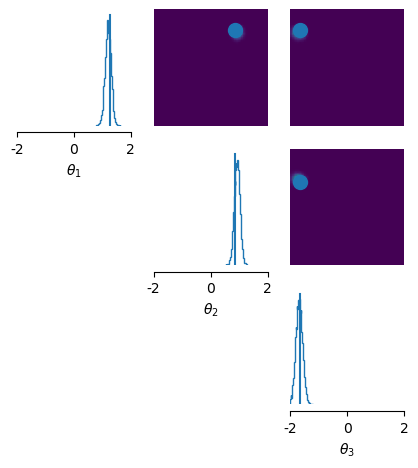

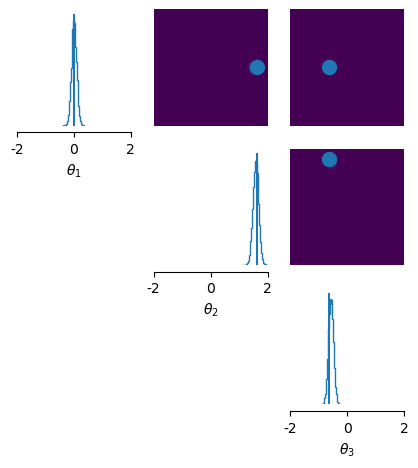

In [2]:
#Applying two sets of distinct observations
theta_1 = prior.sample((1,))
xobs_1 = simulator(theta_1)

theta_2 = prior.sample((1,))
xobs_2 = simulator(theta_2)

#without running twice the inference step, we can generate two sets of 'observed' data, xobs_1 and xobs_2
#and evaluate posteriors given the two parameters theta_1 and theta_2

posterior_samples_1 = posterior.sample((10000,), x=xobs_1)

#plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_1
)

posterior_samples_2 = posterior.sample((10000,), x=xobs_2)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_2, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_2
)

**Multi-round NPE** \
used when interested in very few number of sets of observational data, therefore can train the network multiple times to get a better posterior estimation. \
Process goes: prior+simulator --> posterior + simulated data from data --> input simulated data to train posterior again --> draw more data from the new posterior--> train posterior again... until a desired accuracy is achieved.

In [3]:
#use the same prior and simulator models from before
num_dim=3

def simulator(theta):
    #simulated data from a gaussian noise
    return theta + torch.randn_like(theta) * 0.1 + 1  

prior = utils.BoxUniform(-2*torch.ones(num_dim),2*torch.ones(num_dim))

#check simulated data and prior inputs
simulator, prior = prepare_for_sbi(simulator, prior)

#inference
inference = SNPE(prior=prior)
num_sim = 500

num_rounds = 2 #train two rounds

x_o = torch.zeros(num_dim,)  #infer the posterior around this 'observation' point, ie conditioning on this data
#will cause different outcomes of posterior if conditioned on different x_o

posteriors = [] #initialise posterior
proposal = prior #initialise proposal distribution to be the prior 
thetas = []

for _ in range(num_rounds):
    theta, xobs = simulate_for_sbi(simulator=simulator, proposal=proposal, num_simulations=500)
    inference = inference.append_simulations(theta, xobs, proposal=proposal)  #simulate and train the model based on the proposal function 
    #which will be updated at the end of loop
    density_estimator = inference.train()
    posterior = inference.build_posterior(density_estimator)
    posteriors.append(posterior)
    proposal = posterior.set_default_x(x_o)  #update proposal for the next round as posterior estimated
    #new data is then simulated from the posterior
    thetas.append(theta)

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 76 epochs.

Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 67 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

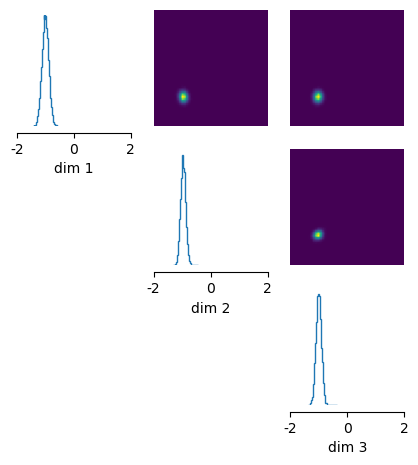

In [4]:
#visualisation
posterior_samples = posterior.sample((10000,), x=x_o)

_ = analysis.pairplot(
    posterior_samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5)
)

**Embedding space** \
Embedding networks reduce the dimensionality of data to a low-D representation based on certain charateristics of the sample data.

**Fisher Information calculation** \
Fisher information is defined as the variance of the gradient of log likelihood, which quantifies the 'amount' of information of the true parameter (eg. a mean) carried by a distribution that models the observed sample. For dimensions higher than 1D, it takes a DxD matrix form that includes covariance between variables of the multi-variable distribution.

Fisher information from sample set 1 =0.8684508948997302, from set 2 =0.6544568478418697, from set 3 =1.1194562897966476


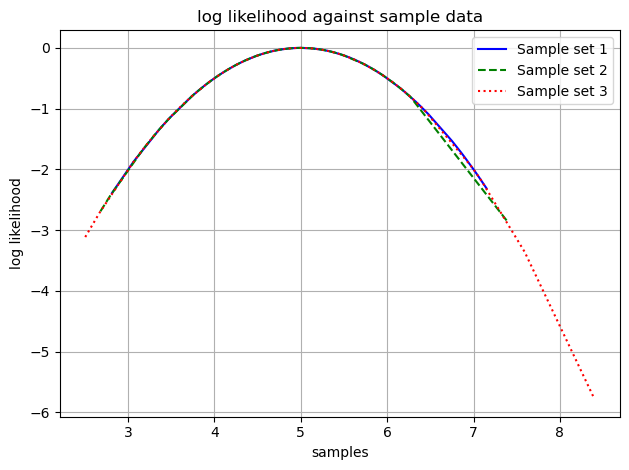

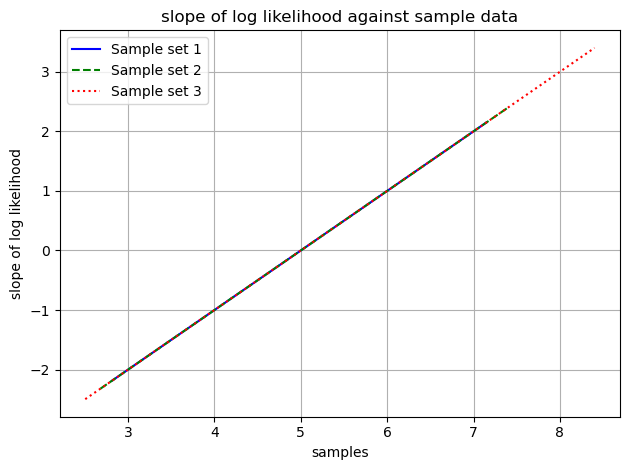

In [23]:
#1D example
# plan is to generate several random distribution of sample points from the true mu distribution 
# and calculate Fisher information of each sample sets and find the one sample set that best resembles the true distribution 
import numpy as np
import matplotlib.pyplot as plt
import torch
np.random.seed(13)

true_mu = 5
true_sd = 1

def log_likelihood(mu, sd, sample):
    ll = []
    for data in sample:
        ll.append(-0.5 * (data - mu)**2 / (sd**2))
    return ll

def slope_ll(mu, sd, sample):  #slope of log likelihood function wrt parameter mu
    slope = []
    for data in sample:
        slope.append( (data - mu) / (sd**2))
    return slope

#take 3 x 100 random sample points from the true distribution
sample1 = np.sort(np.random.normal(true_mu, true_sd, size=100))
sample2 = np.sort(np.random.normal(true_mu, true_sd, size=100)) 
sample3 = np.sort(np.random.normal(true_mu, true_sd, size=100))

FI1 = np.var(slope_ll(true_mu, true_sd, sample1))
FI2 = np.var(slope_ll(true_mu, true_sd, sample2))
FI3 = np.var(slope_ll(true_mu, true_sd, sample3))
print(f'Fisher information from sample set 1 ={FI1}, from set 2 ={FI2}, from set 3 ={FI3}')

plt.figure()
plt.plot(sample1, log_likelihood(true_mu, true_sd, sample1), label='Sample set 1', color='blue', linestyle='-')
plt.plot(sample2, log_likelihood(true_mu, true_sd, sample2), label='Sample set 2', color='green', linestyle='--')
plt.plot(sample3, log_likelihood(true_mu, true_sd, sample3), label='Sample set 3', color='red', linestyle=':')
plt.xlabel('samples')
plt.ylabel('log likelihood')
plt.title('log likelihood against sample data')
plt.legend()
plt.tight_layout()
plt.grid(True)

plt.figure()
plt.plot(sample1, slope_ll(true_mu, true_sd, sample1), label='Sample set 1', color='blue', linestyle='-')
plt.plot(sample2, slope_ll(true_mu, true_sd, sample2), label='Sample set 2', color='green', linestyle='--')
plt.plot(sample3, slope_ll(true_mu, true_sd, sample3), label='Sample set 3', color='red', linestyle=':')
plt.xlabel('samples')
plt.ylabel('slope of log likelihood')
plt.title('slope of log likelihood against sample data')
plt.legend()
plt.tight_layout()
plt.grid(True)

plt.show()


In this trial even though the 3 sample sets of data produced (seemingly) perfectly overlapping log likelihood and score function, their respective Fisher information came out to be different, this is expected as the sample size (=100) is not sufficiently large to cancel out the naturally occuring noise in random sampling and that the Fisher information is very sensitive to small differences between points. Had the sample size be sufficiently large the FI's could converge better.

Fisher information from sample set 1 =0.9897114436826278, from set 2 =1.0074879034574729, from set 3 =1.0225733341212366, better convergence seen!


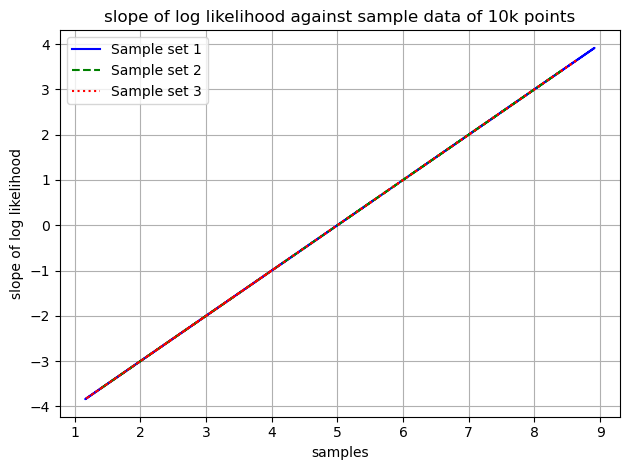

In [25]:
#take 3 x 10000 random sample points from the true distribution
sample1 = np.random.normal(true_mu, true_sd, size=10000) 
sample2 = np.random.normal(true_mu, true_sd, size=10000) 
sample3 = np.random.normal(true_mu, true_sd, size=10000) 

FI1 = np.var(slope_ll(true_mu, true_sd, sample1))
FI2 = np.var(slope_ll(true_mu, true_sd, sample2))
FI3 = np.var(slope_ll(true_mu, true_sd, sample3))
print(f'Fisher information from sample set 1 ={FI1}, from set 2 ={FI2}, from set 3 ={FI3}, better convergence seen!')

plt.figure()
plt.plot(sample1, slope_ll(true_mu, true_sd, sample1), label='Sample set 1', color='blue', linestyle='-')
plt.plot(sample2, slope_ll(true_mu, true_sd, sample2), label='Sample set 2', color='green', linestyle='--')
plt.plot(sample3, slope_ll(true_mu, true_sd, sample3), label='Sample set 3', color='red', linestyle=':')
plt.xlabel('samples')
plt.ylabel('slope of log likelihood')
plt.title('slope of log likelihood against sample data of 10k points')
plt.legend()
plt.tight_layout()
plt.grid(True)

plt.show()